In [3]:
import pandas as pd
import numpy as np

data = pd.read_csv('data.csv')
print(data.head())

print(data.describe())
print(data.isnull().sum())


         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [4]:
data = data.drop(columns=['Unnamed: 32', 'id'])
data = data.dropna()

C:\Users\typal\AppData\Local\Temp\ipykernel_3912\1619774853.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=data, palette='magma')


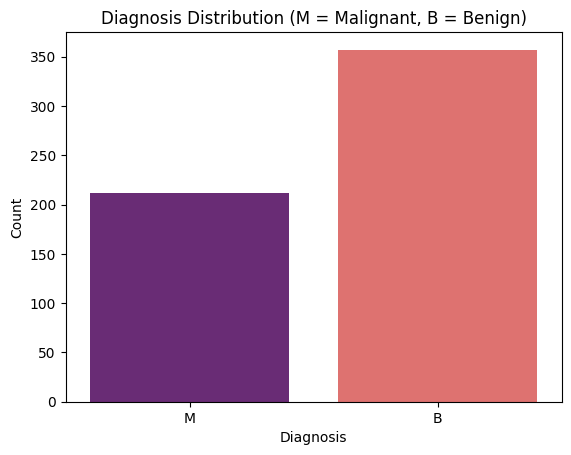

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Countplot with magma palette
sns.countplot(x='diagnosis', data=data, palette='magma')
plt.title('Diagnosis Distribution (M = Malignant, B = Benign)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

In [6]:
unique, counts = np.unique(data['diagnosis'], return_counts=True)
print(dict(zip(unique, counts)))

{'B': 357, 'M': 212}


In [7]:
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


lr = LogisticRegression()
lr.fit(X_train, y_train)
print("Logistic Regression Accuracy:", lr.score(X_test, y_test))

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
print("K-Nearest Neighbors Accuracy:", knn_model.score(X_test, y_test))

c:\Users\typal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.956140350877193
K-Nearest Neighbors Accuracy: 0.956140350877193


In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest Accuracy:", rf.score(X_test, y_test))

Random Forest Accuracy: 0.9649122807017544


In [12]:
svc = SVC(kernel='linear', random_state=42)
svc.fit(X_train, y_train)
print("Support Vector Machine Accuracy:", svc.score(X_test, y_test))

Support Vector Machine Accuracy: 0.956140350877193


In [14]:
print("Best Model and score:", max(lr.score(X_test, y_test), knn_model.score(X_test, y_test), rf.score(X_test, y_test), svc.score(X_test, y_test)), "with model:", ["Logistic Regression", "K-Nearest Neighbors", "Random Forest", "Support Vector Machine"][np.argmax([lr.score(X_test, y_test), knn_model.score(X_test, y_test), rf.score(X_test, y_test), svc.score(X_test, y_test)])])


Best Model and score: 0.9649122807017544 with model: Random Forest
